### TP1 - Big Data
Integrantes: F. Pascale, C. Efkhanian y J. Notario

# Parte 1: Familiarizándonos con la EPH y limpieza

### Bibliotecas

In [52]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

### Directorio

In [53]:
directorio = "/Users/mariapascale/Documents/E337 | Big Data/E337_Grupo1/TP1"
os.chdir(directorio)
print(os.getcwd())



/Users/mariapascale/Documents/E337 | Big Data/E337_Grupo1/TP1


In [54]:
df_2005_raw = pd.read_stata('usu_individual_3105.dta', convert_categoricals=False, convert_missing=False)
df_2005_raw['EMPLEO'] = np.nan

df_2025_raw = pd.read_excel('usu_individual_T325.xls')

In [55]:
df_2005_raw.head(4)
df_2025_raw.head(4)

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,8,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,9,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0


### Elegimos las variables y verificamos cómo están compuestas las variables de los DataFrames

In [56]:
# Pasamos todas las variables a mayúsculas para armonizarlas:
df_2005_raw.columns = df_2005_raw.columns.str.upper().str.strip()
df_2025_raw.columns = df_2025_raw.columns.str.upper().str.strip()

# Elegimos variables:
variables = ['ANO4', 'PONDERA', 'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED',
             'ESTADO', 'CAT_INAC', 'IPCF', 'CAT_OCUP', 'PP07H', 'P21', 
             'PP04A', 'EMPLEO']

# Tamaño de las variables
print("\n TAMAÑO DE CADA BASE (sin filtrar)")
print(f"  2005: {df_2005_raw.shape[0]:,} filas x {df_2005_raw.shape[1]} columnas")
print(f"  2025: {df_2025_raw.shape[0]:,} filas x {df_2025_raw.shape[1]} columnas")

# Tipos de datos dentro de las variables
print("\n TIPO DE DATO POR VARIABLE")
print(f"  {'Variable':<12}  {'dtype 2005':>12}  {'dtype 2025':>12}")
for v in variables:
    d05 = str(df_2005_raw[v].dtype) if v in df_2005_raw.columns else "AUSENTE"
    d25 = str(df_2025_raw[v].dtype) if v in df_2025_raw.columns else "AUSENTE"
    flag = "  <<< DISTINTOS" if d05 != d25 else ""
    print(f"  {v:<12}  {d05:>12}  {d25:>12}{flag}")


# Acá vemos cuántas N/As hay en las variables antes de hacer el merge. La idea es que después de hacer el merge nos volvamos a 
# fijar cuantas N/As hay, y si concuerdan, se hizo bien el merge.
print("\n % NaN POR VARIABLE (antes de limpiar)")
print(f"  {'Variable':<12}  {'NaN% 2005':>10}  {'NaN% 2025':>10}")
for v in variables:
    p05 = df_2005_raw[v].isnull().sum() / len(df_2005_raw) * 100 if v in df_2005_raw.columns else float('nan')
    p25 = df_2025_raw[v].isnull().sum() / len(df_2025_raw) * 100 if v in df_2025_raw.columns else float('nan')
    print(f"  {v:<12}  {p05:>9.1f}%  {p25:>9.1f}%")


 TAMAÑO DE CADA BASE (sin filtrar)
  2005: 47,647 filas x 177 columnas
  2025: 16,383 filas x 235 columnas

 TIPO DE DATO POR VARIABLE
  Variable        dtype 2005    dtype 2025
  ANO4               float64         int64  <<< DISTINTOS
  PONDERA            float64         int64  <<< DISTINTOS
  CH04               float64         int64  <<< DISTINTOS
  CH06               float64         int64  <<< DISTINTOS
  CH07               float64         int64  <<< DISTINTOS
  CH08               float64         int64  <<< DISTINTOS
  NIVEL_ED           float64         int64  <<< DISTINTOS
  ESTADO             float64         int64  <<< DISTINTOS
  CAT_INAC           float64         int64  <<< DISTINTOS
  IPCF               float64       float64
  CAT_OCUP           float64         int64  <<< DISTINTOS
  PP07H              float64       float64
  P21                float64         int64  <<< DISTINTOS
  PP04A              float64       float64
  EMPLEO             float64       float64

 % NaN POR

### Limpieza y merge de los DataFrames

In [57]:
# Primero, filtramos sólo por las columnas que incluyen al Gran Buenos Aires (para ambos DataFrames):

# Para esta sección, utilizamos ayuda de la IA. 

# Paso 1: Filtrar GBA 
df_2005 = df_2005_raw[df_2005_raw['REGION'] == 1].copy()
df_2025 = df_2025_raw[df_2025_raw['REGION'] == 1].copy()

print(f"\n[Paso 1] Filtro GBA")
print(f"  2005: {len(df_2005):,} observaciones")
print(f"  2025: {len(df_2025):,} observaciones")


[Paso 1] Filtro GBA
  2005: 9,420 observaciones
  2025: 2,709 observaciones


In [58]:
# Paso 2: Seleccionar las 15 variables

df_2005['EMPLEO'] = np.nan # como EMPLEO no esta en 2005, la creamos con N/As

variables = ['ANO4', 'PONDERA', 'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED',
             'ESTADO', 'CAT_INAC', 'IPCF', 'CAT_OCUP', 'PP07H', 'P21', 
             'PP04A', 'EMPLEO']

df_2005 = df_2005[variables].copy()
df_2025 = df_2025[variables].copy()

print(f"\n[Paso 2] Variables seleccionadas: {variables}")


[Paso 2] Variables seleccionadas: ['ANO4', 'PONDERA', 'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED', 'ESTADO', 'CAT_INAC', 'IPCF', 'CAT_OCUP', 'PP07H', 'P21', 'PP04A', 'EMPLEO']


In [59]:
# Paso 3: Convertir todo a float64 
#  Como 2005 viene como float64 desde Stata y 2025 como int64 desde Excel, convertimos todo a float64 para unificar tipos y poder usar NaN.

print("\n[Paso 3] Conversión de tipos a float64")

df_2005['ANO4']     = pd.to_numeric(df_2005['ANO4'],     errors='coerce')
df_2005['PONDERA']  = pd.to_numeric(df_2005['PONDERA'],  errors='coerce')
df_2005['CH04']     = pd.to_numeric(df_2005['CH04'],     errors='coerce')
df_2005['CH06']     = pd.to_numeric(df_2005['CH06'],     errors='coerce')
df_2005['CH07']     = pd.to_numeric(df_2005['CH07'],     errors='coerce')
df_2005['CH08']     = pd.to_numeric(df_2005['CH08'],     errors='coerce')
df_2005['NIVEL_ED'] = pd.to_numeric(df_2005['NIVEL_ED'], errors='coerce')
df_2005['ESTADO']   = pd.to_numeric(df_2005['ESTADO'],   errors='coerce')
df_2005['CAT_INAC'] = pd.to_numeric(df_2005['CAT_INAC'], errors='coerce')
df_2005['IPCF']     = pd.to_numeric(df_2005['IPCF'],     errors='coerce')
df_2005['CAT_OCUP'] = pd.to_numeric(df_2005['CAT_OCUP'], errors='coerce')
df_2005['PP07H']    = pd.to_numeric(df_2005['PP07H'],    errors='coerce')
df_2005['P21']      = pd.to_numeric(df_2005['P21'],      errors='coerce')
df_2005['PP04A']    = pd.to_numeric(df_2005['PP04A'],    errors='coerce')
df_2005['EMPLEO']   = pd.to_numeric(df_2005['EMPLEO'],   errors='coerce')

df_2025['ANO4']     = pd.to_numeric(df_2025['ANO4'],     errors='coerce')
df_2025['PONDERA']  = pd.to_numeric(df_2025['PONDERA'],  errors='coerce')
df_2025['CH04']     = pd.to_numeric(df_2025['CH04'],     errors='coerce')
df_2025['CH06']     = pd.to_numeric(df_2025['CH06'],     errors='coerce')
df_2025['CH07']     = pd.to_numeric(df_2025['CH07'],     errors='coerce')
df_2025['CH08']     = pd.to_numeric(df_2025['CH08'],     errors='coerce')
df_2025['NIVEL_ED'] = pd.to_numeric(df_2025['NIVEL_ED'], errors='coerce')
df_2025['ESTADO']   = pd.to_numeric(df_2025['ESTADO'],   errors='coerce')
df_2025['CAT_INAC'] = pd.to_numeric(df_2025['CAT_INAC'], errors='coerce')
df_2025['IPCF']     = pd.to_numeric(df_2025['IPCF'],     errors='coerce')
df_2025['CAT_OCUP'] = pd.to_numeric(df_2025['CAT_OCUP'], errors='coerce')
df_2025['PP07H']    = pd.to_numeric(df_2025['PP07H'],    errors='coerce')
df_2025['P21']      = pd.to_numeric(df_2025['P21'],      errors='coerce')
df_2025['PP04A']    = pd.to_numeric(df_2025['PP04A'],    errors='coerce')
df_2025['EMPLEO']    = pd.to_numeric(df_2025['EMPLEO'],    errors='coerce')


[Paso 3] Conversión de tipos a float64


In [60]:
# Paso 4: Forzar ANO4 
df_2005['ANO4'] = 2005
df_2025['ANO4'] = 2025

In [61]:
# Paso 5: Limpiar códigos sin sentido → NaN 
print("\n Limpieza de códigos sin sentido")

# CH06: -1 = edad invalida q aparece n ambas bases
df_2005['CH06'] = df_2005['CH06'].replace(-1, np.nan)
df_2025['CH06'] = df_2025['CH06'].replace(-1, np.nan)
print("  CH06: -1 → NaN (edad inválida)")

# CH07: 9 = Ns/Nr
df_2005['CH07'] = df_2005['CH07'].replace(9, np.nan)
df_2025['CH07'] = df_2025['CH07'].replace(9, np.nan)
print("  CH07: 9 → NaN (Ns/Nr)")

# CH08: 9 = Ns/Nr; 123 solo aparece en 2005 (combinación OS+mutual+seg.pub),
#        es válido y consistente con el diccionario → se conserva
df_2005['CH08'] = df_2005['CH08'].replace(9, np.nan)
df_2025['CH08'] = df_2025['CH08'].replace(9, np.nan)
print("  CH08: 9 → NaN (Ns/Nr); 123 se conserva (combo válido según diccionario)")

# PP04A: 0 = no aplica (no ocupado), 9 = Ns/Nr
df_2005['PP04A'] = df_2005['PP04A'].replace(0, np.nan)
df_2005['PP04A'] = df_2005['PP04A'].replace(9, np.nan)
df_2025['PP04A'] = df_2025['PP04A'].replace(0, np.nan)
df_2025['PP04A'] = df_2025['PP04A'].replace(9, np.nan)
print("  PP04A: 0 y 9 → NaN (no aplica / Ns/Nr)")


# P21 e IPCF: valores negativos son códigos de no respuesta, no ingresos reales
#   2005: no había negativos (confirmado en diagnóstico)
#   2025: -9 = no respuesta
df_2005.loc[df_2005['P21']  < 0, 'P21']  = np.nan
df_2005.loc[df_2005['IPCF'] < 0, 'IPCF'] = np.nan
df_2025.loc[df_2025['P21']  < 0, 'P21']  = np.nan
df_2025.loc[df_2025['IPCF'] < 0, 'IPCF'] = np.nan
print("  P21 e IPCF: valores < 0 → NaN (códigos de no respuesta)")


 Limpieza de códigos sin sentido
  CH06: -1 → NaN (edad inválida)
  CH07: 9 → NaN (Ns/Nr)
  CH08: 9 → NaN (Ns/Nr); 123 se conserva (combo válido según diccionario)
  PP04A: 0 y 9 → NaN (no aplica / Ns/Nr)
  P21 e IPCF: valores < 0 → NaN (códigos de no respuesta)


In [62]:
# Paso 6 concatenar
print("\n Concatenando bases")
df_final = pd.concat([df_2005, df_2025], ignore_index=True)


 Concatenando bases


In [63]:
# Resultados del Merge

print("\n")
print("RESULTADO FINAL")
print("\n")
print(f"  Filas tot : {len(df_final):,}")
print(f"  Filas 2005    : {(df_final['ANO4'] == 2005).sum():,}")
print(f"  Filas 2025    : {(df_final['ANO4'] == 2025).sum():,}")
print(f"  Columnas      : {df_final.shape[1]}")
print("\n    % NaN por variable:")
print(f"  {'Variable':<12} {'NaN% total':>10} {'NaN% 2005':>10}  {'NaN% 2025':>10} Motivo")

motivos = {
    'ANO4'    : 'No aplica',
    'PONDERA' : 'No aplica',
    'CH04'    : 'No aplica',
    'CH06'    : 'Edad -1 limpiada',
    'CH07'    : 'Ns/Nr limpiado',
    'CH08'    : 'Ns/Nr limpiado',
    'NIVEL_ED': 'No aplica',
    'ESTADO'  : "No aplica",
    'CAT_INAC': 'No aplica',
    'IPCF'    : 'No aplica',
    'CAT_OCUP': 'No aplica',
    'PP07H'   : 'Solo aplica a ocupados',
    'P21'     : 'Solo quien tuvo ingreso laboral',
    'PP04A'   : 'Solo aplica a ocupados',
    'EMPLEO'  : 'Falta en 2005',
}

for col in variables:
    pct_tot = df_final[col].isnull().sum() / len(df_final) * 100
    pct_05  = df_2005[col].isnull().sum()  / len(df_2005)  * 100
    pct_25  = df_2025[col].isnull().sum()  / len(df_2025)  * 100
    print(f"  {col:<12}  {pct_tot:>9.1f}%  {pct_05:>9.1f}%  {pct_25:>9.1f}%  {motivos.get(col,'')}")

df_final.to_csv('eph_gba_merged.csv', index=False) # pasa el merge a csv
print("\n  Base guardada como 'eph_gba_merged.csv")



RESULTADO FINAL


  Filas tot : 12,129
  Filas 2005    : 9,420
  Filas 2025    : 2,709
  Columnas      : 15

    % NaN por variable:
  Variable     NaN% total  NaN% 2005   NaN% 2025 Motivo
  ANO4                0.0%        0.0%        0.0%  No aplica
  PONDERA             0.0%        0.0%        0.0%  No aplica
  CH04                0.0%        0.0%        0.0%  No aplica
  CH06                1.3%        1.5%        0.4%  Edad -1 limpiada
  CH07                0.0%        0.0%        0.2%  Ns/Nr limpiado
  CH08                0.1%        0.2%        0.0%  Ns/Nr limpiado
  NIVEL_ED            0.0%        0.0%        0.0%  No aplica
  ESTADO              0.0%        0.0%        0.0%  No aplica
  CAT_INAC            0.0%        0.0%        0.0%  No aplica
  IPCF                0.0%        0.0%        0.0%  No aplica
  CAT_OCUP            0.0%        0.0%        0.0%  No aplica
  PP07H              11.5%        0.0%       51.5%  Solo aplica a ocupados
  P21                 3.5%        0

#### Inciso (d): Heatmap

In [64]:
# Abrimos la base en formato pd

df_eph_GBA = pd.read_csv('eph_gba_merged.csv')

df_eph_GBA.head() 

,ANO4,PONDERA,CH04,CH06,CH07,CH08,NIVEL_ED,ESTADO,CAT_INAC,IPCF,CAT_OCUP,PP07H,P21,PP04A,EMPLEO
0,2005,1542.0,1.0,37.0,2.0,1.0,5.0,1.0,0.0,500.0,3.0,1.0,1000.0,1.0,NaN
1,2005,1542.0,2.0,37.0,2.0,1.0,6.0,1.0,0.0,500.0,3.0,1.0,1000.0,1.0,NaN
2,2005,1542.0,1.0,9.0,5.0,1.0,1.0,4.0,3.0,500.0,0.0,0.0,0.0,NaN,NaN
3,2005,1542.0,1.0,7.0,5.0,1.0,1.0,4.0,3.0,500.0,0.0,0.0,0.0,NaN,NaN
4,2005,1256.0,1.0,37.0,2.0,1.0,3.0,1.0,0.0,250.0,3.0,1.0,1000.0,2.0,NaN


In [65]:
# Reutilizamos el código que usamos antes para sacar los porcentajes de NaN por columna:
list_2005_pct = []
list_2025_pct = []

for col in variables:
    pct_tot = df_final[col].isnull().sum() / len(df_final) * 100
    pct_05  = df_2005[col].isnull().sum()  / len(df_2005)  * 100
    list_2005_pct.append(pct_05)

    pct_25  = df_2025[col].isnull().sum()  / len(df_2025)  * 100
    list_2025_pct.append(pct_25)

    print(f"  {col:<12}  {pct_tot:>9.1f}%  {pct_05:>9.1f}%  {pct_25:>9.1f}%  {motivos.get(col,'')}")

# Lo que hacemos acá es guardar los porcentajes de missing values de cada año en dos listas distintas. Próximamente, las uniremos en una matriz. 

  ANO4                0.0%        0.0%        0.0%  No aplica
  PONDERA             0.0%        0.0%        0.0%  No aplica
  CH04                0.0%        0.0%        0.0%  No aplica
  CH06                1.3%        1.5%        0.4%  Edad -1 limpiada
  CH07                0.0%        0.0%        0.2%  Ns/Nr limpiado
  CH08                0.1%        0.2%        0.0%  Ns/Nr limpiado
  NIVEL_ED            0.0%        0.0%        0.0%  No aplica
  ESTADO              0.0%        0.0%        0.0%  No aplica
  CAT_INAC            0.0%        0.0%        0.0%  No aplica
  IPCF                0.0%        0.0%        0.0%  No aplica
  CAT_OCUP            0.0%        0.0%        0.0%  No aplica
  PP07H              11.5%        0.0%       51.5%  Solo aplica a ocupados
  P21                 3.5%        0.0%       15.5%  Solo quien tuvo ingreso laboral
  PP04A              55.5%       56.6%       51.5%  Solo aplica a ocupados
  EMPLEO             89.2%      100.0%       51.5%  Falta en 2005


[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.5074309978768579), np.float64(0.0), np.float64(0.15923566878980894), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(56.63481953290871), np.float64(100.0)]
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.4060538944259874), np.float64(0.18456995201181248), np.float64(0.03691399040236249), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(51.531930601698036), np.float64(15.503875968992247), np.float64(51.531930601698036), np.float64(51.531930601698036)]
ANO4
2005    9420
2025    2709
Name: count, dtype: int64


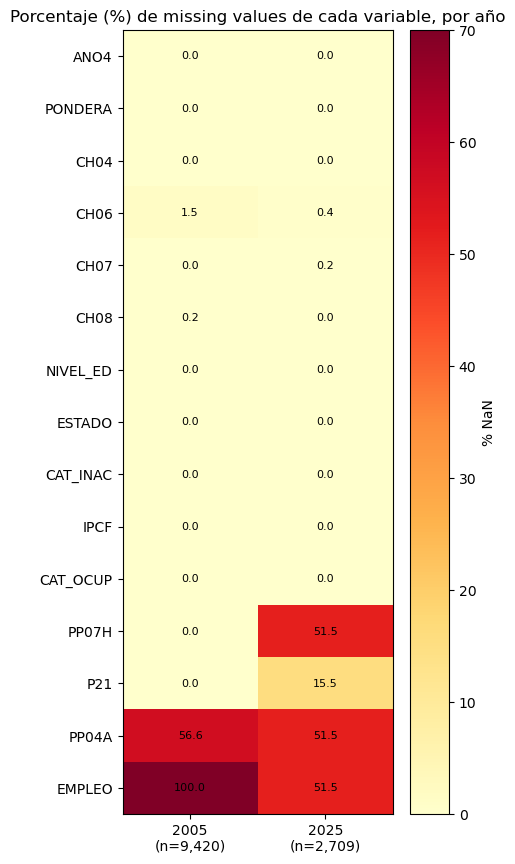

In [66]:
# Ahora, armamos el heatmap. Para esta sección, utilizamos ayuda de la IA. 
# eje x: año.
# eje y: nombres de las variables. 
# datos: en la matriz que vamos a crear. 
nombres_var = ['ANO4', 'PONDERA', 'CH04', 'CH06', 'CH07', 'CH08', 'NIVEL_ED',
             'ESTADO', 'CAT_INAC', 'IPCF', 'CAT_OCUP', 'PP07H', 'P21', 
             'PP04A', 'EMPLEO']
print(list_2005_pct)
print(list_2025_pct)

# Contamos cantidad de observaciones por año:
ano = [2005, 2025]

count = df_eph_GBA['ANO4'].value_counts() # para cada año, este código nos dice el número de observaciones

print(count)

obs_2005 = 9420
obs_2025 = 2709

matriz = np.array([list_2005_pct, list_2025_pct]) # unimos las listas de ambos años en una matriz

ffig, ax = plt.subplots(figsize=(5, 9)) 

im = ax.imshow(matriz.T, aspect='auto', vmin=0, vmax=70, cmap="YlOrRd")

ax.set_xticks(range(len(ano)), labels=[f"2005\n(n={obs_2005:,})", f"2025\n(n={obs_2025:,})"])
ax.set_yticks(range(len(nombres_var)), labels=nombres_var)

for i in range(len(nombres_var)):
    for j in range(len(ano)):
        text = ax.text(j, i, f"{matriz.T[i, j]:.1f}",
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax, label="% NaN")
ax.set_title("Porcentaje (%) de missing values de cada variable, por año")
plt.tight_layout(pad=2.0)
plt.savefig('Heatmap.png', bbox_inches='tight', dpi=300)
plt.show()

# Parte 2: Primer análisis exploratorio

### Ejercicio 3

52.86624203821656 47.13375796178344
52.86624203821656 47.13375796178344


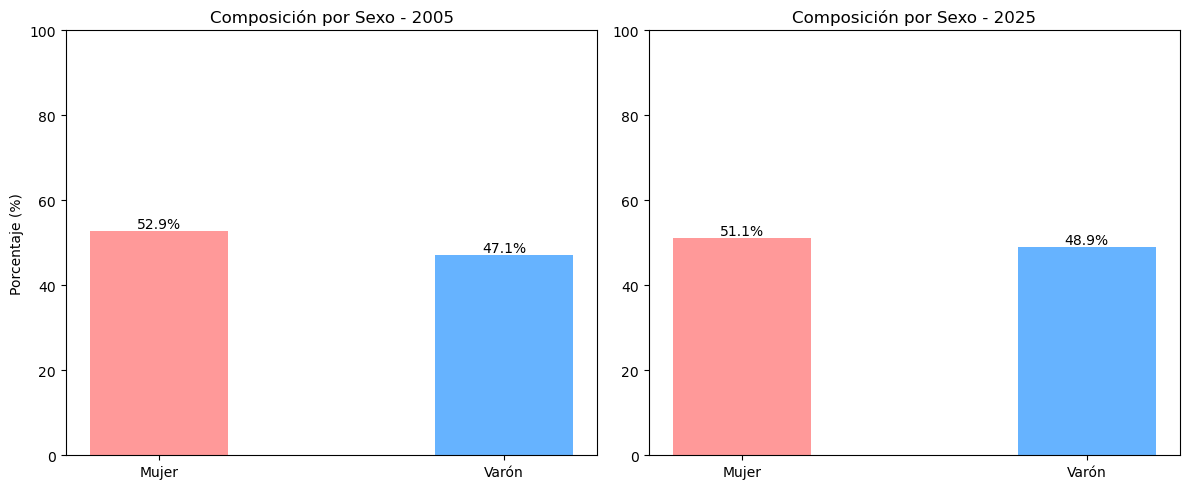

In [67]:
# Punto 3: Gráfico de barras por sexo.

sexo = ["Mujer", "Varón"]

dataf_2005 = df_eph_GBA[df_eph_GBA['ANO4'] == 2005]

dataf_2025 = df_eph_GBA[df_eph_GBA['ANO4'] == 2025]

# Sacamos proporción de varones y de mujeres en el 2005:

pct_mujeres_2005 = (dataf_2005['CH04'] == 2).sum() / len(dataf_2005) * 100

pct_varones_2005 = 100 - pct_mujeres_2005

print(pct_mujeres_2005, pct_varones_2005)

# Sacamos proporción de varones y de mujeres en el 2025:

pct_mujeres_2025 = (dataf_2025['CH04'] == 2).sum() / len(dataf_2025) * 100

pct_varones_2025 = 100 - pct_mujeres_2025

print(pct_mujeres_2005, pct_varones_2005)

# Realizamos dos gráficos de barras conjuntos:
datos_sex_05 = [pct_mujeres_2005, pct_varones_2005]

datos_sex_25 = [pct_mujeres_2025, pct_varones_2025]

colores = ['#ff9999','#66b3ff']

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

### Gráfico 2005:
ax[0].bar(sexo, datos_sex_05, color=colores, width=0.4)
ax[0].set_title('Composición por Sexo - 2005')
ax[0].set_ylabel('Porcentaje (%)')
ax[0].set_ylim(0, 100)

### Gráfico 2025:
ax[1].bar(sexo, datos_sex_25, color=colores, width=0.4)
ax[1].set_title('Composición por Sexo - 2025')
ax[1].set_ylim(0, 100)

for i in range(2):
    for bar in ax[i].patches:
        ax[i].annotate(f'{bar.get_height():.1f}%', 
                       (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                       ha='center', va='bottom')
plt.tight_layout(pad=2.0)
plt.savefig('ComposiciónSexo.png', bbox_inches='tight', dpi=300)

plt.tight_layout()
plt.show()


### Ejercicio 4

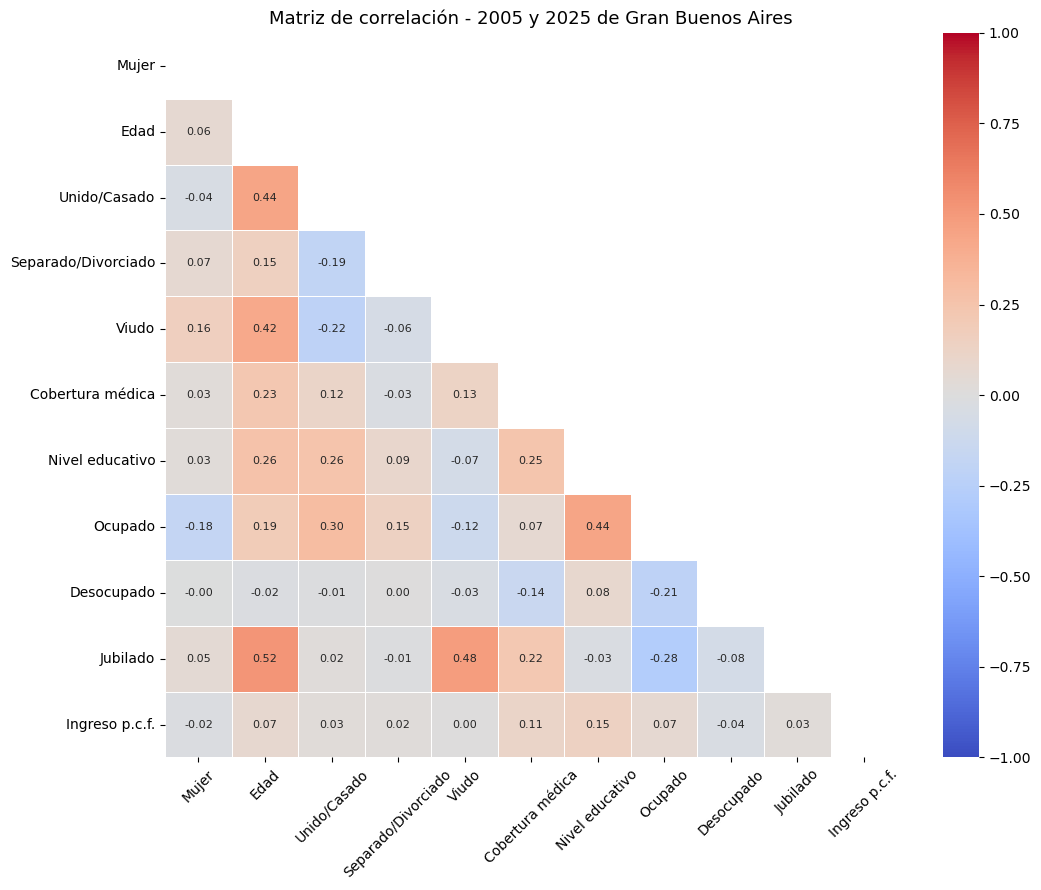

In [68]:
# Punto 4: Heatmap de correlación.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una nueva dataframe usando pandas con los contenidos de la dataframe anterior pero con nombres autocontenidos y categóricos:
vars_total = pd.DataFrame()
vars_total['Mujer']               = (df_eph_GBA['CH04'] == 2).astype(float)
vars_total['Edad']                = df_eph_GBA['CH06']
vars_total['Unido/Casado']        = (df_eph_GBA['CH07'].isin([1, 2])).astype(float)
vars_total['Separado/Divorciado'] = (df_eph_GBA['CH07'] == 3).astype(float)
vars_total['Viudo']               = (df_eph_GBA['CH07'] == 4).astype(float)
vars_total['Cobertura médica']    = (df_eph_GBA['CH08'] != 4).astype(float)
vars_total['Nivel educativo']     = df_eph_GBA['NIVEL_ED'].map({7:1, 1:2, 2:3, 3:4, 4:5, 5:6, 6:7})
vars_total['Ocupado']             = (df_eph_GBA['ESTADO'] == 1).astype(float)
vars_total['Desocupado']          = (df_eph_GBA['ESTADO'] == 2).astype(float)
vars_total['Jubilado']            = (df_eph_GBA['CAT_INAC'] == 1).astype(float)
vars_total['Ingreso p.c.f.']      = df_eph_GBA['IPCF']

# Armamos la atriz de correlación:
corr = vars_total.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

# Armamos el heatmap de correlación, con título, correlaciones dentro de las celdas y sin la parte redundante de la matriz:
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr,
            ax=ax,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1, vmax=1,
            mask=mask,
            linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Matriz de correlación - 2005 y 2025 de Gran Buenos Aires', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('matriz_correlacion_gba_punto_4.png', dpi=150, bbox_inches='tight')
plt.show()


# Parte 3: Conociendo el mercado laboral

### Ejercicio 5

In [69]:
# Punto 5: separar los respondieron de los no respondieron.

norespondieron = df_eph_GBA[df_eph_GBA['ESTADO'] == 0].copy()
respondieron   = df_eph_GBA[df_eph_GBA['ESTADO'] != 0].copy()

print("No respondieron (ESTADO = 0):", len(norespondieron))
print("Respondieron    (ESTADO ≠ 0):", len(respondieron))

No respondieron (ESTADO = 0): 11
Respondieron    (ESTADO ≠ 0): 12118


### Ejercicio 6

In [70]:
# Punto 6: sólo ocupados.

ocupados = respondieron[respondieron['ESTADO'] == 1].copy()

print("Ocupados (ESTADO = 1):", len(ocupados))

Ocupados (ESTADO = 1): 5401


### Ejercicio 7

In [71]:
# Punto 7 — Crear variable informal.

# Trabajadores informales: asalariados sin descuento jubilatorio (CAT_OCUP=3 y PP07H=2) o trabajadores familiares sin remuneración (CAT_OCUP=4).

ocupados['informal'] = 0

ocupados.loc[(ocupados['CAT_OCUP'] == 3) & (ocupados['PP07H'] == 2), 'informal'] = 1
ocupados.loc[ocupados['CAT_OCUP'] == 4, 'informal'] = 1

print("Formales  (informal = 0):", (ocupados['informal'] == 0).sum())
print("Informales (informal = 1):", (ocupados['informal'] == 1).sum())
print("Tasa de informalidad:", round((ocupados['informal'] == 1).sum() / len(ocupados) * 100, 1), "%")

Formales  (informal = 0): 3624
Informales (informal = 1): 1777
Tasa de informalidad: 32.9 %


### Ejercicio 8

In [72]:
# Punto 8 — Comparar variable informal construida con EMPLEO (solo 2025).

ocupados_2025 = ocupados[ocupados['ANO4'] == 2025].copy()

# Convertir EMPLEO a misma escala que informal (0 = formal, 1 = informal).
# EMPLEO: 1 = Formal → 0, 2 = Informal → 1, 9 = Ns/Nr → NaN.
ocupados_2025['informal_EMPLEO'] = np.nan
ocupados_2025.loc[ocupados_2025['EMPLEO'] == 1, 'informal_EMPLEO'] = 0
ocupados_2025.loc[ocupados_2025['EMPLEO'] == 2, 'informal_EMPLEO'] = 1

# Comparación.
ambas = ocupados_2025[['informal', 'informal_EMPLEO']].dropna()

coinciden    = (ambas['informal'] == ambas['informal_EMPLEO']).sum()
no_coinciden = (ambas['informal'] != ambas['informal_EMPLEO']).sum()
total        = len(ambas)

print(f"Casos comparables (sin Ns/Nr en EMPLEO): {total}")
print(f"Coinciden   : {coinciden}  ({round(coinciden/total*100, 1)}%)")
print(f"No coinciden: {no_coinciden}  ({round(no_coinciden/total*100, 1)}%)")

print("\nTabla de contingencia:")
print(pd.crosstab(ambas['informal'], ambas['informal_EMPLEO'],
                  rownames=['Informal construida'],
                  colnames=['Informal EMPLEO'],
                  margins=True))

Casos comparables (sin Ns/Nr en EMPLEO): 1311
Coinciden   : 1103  (84.1%)
No coinciden: 208  (15.9%)

Tabla de contingencia:
Informal EMPLEO      0.0  1.0   All
Informal construida                
0                    738  208   946
1                      0  365   365
All                  738  573  1311


### Ejercicio 9

ESTADÍSTICAS DESCRIPTIVAS POR CONDICIÓN DE INFORMALIDAD
                   N  Edad promedio  Ingreso ocup. ppal. promedio  Ingreso p.c.f. promedio  % Mujeres  Nivel educ. promedio
Año  Condición                                                                                                             
2005 Informal   1412           37.3                         495.1                    479.4       49.4                   3.3
     Formal     2676           41.3                        1085.4                    783.0       38.3                   4.0
2025 Informal    365           39.0                      535400.0                 260026.0       48.8                   3.9
     Formal      948           43.9                     1124699.8                 538841.2       42.5                   4.3


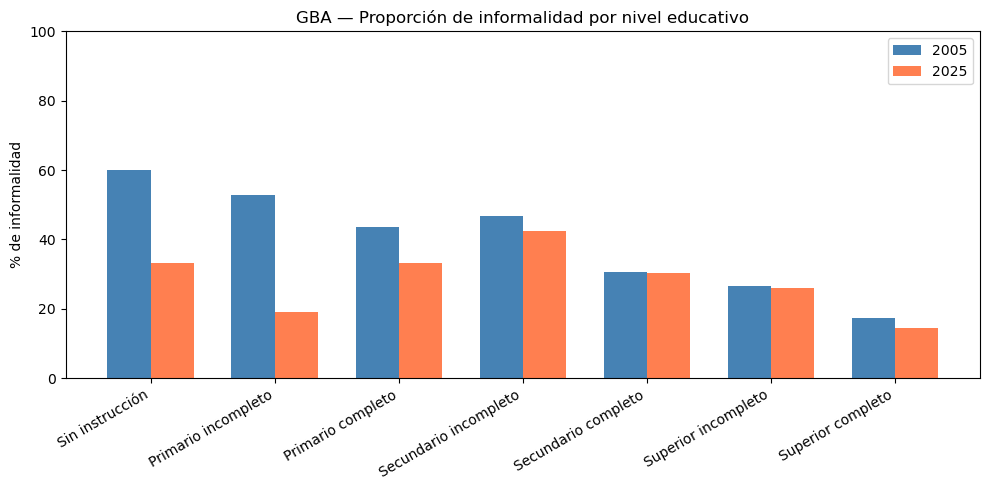

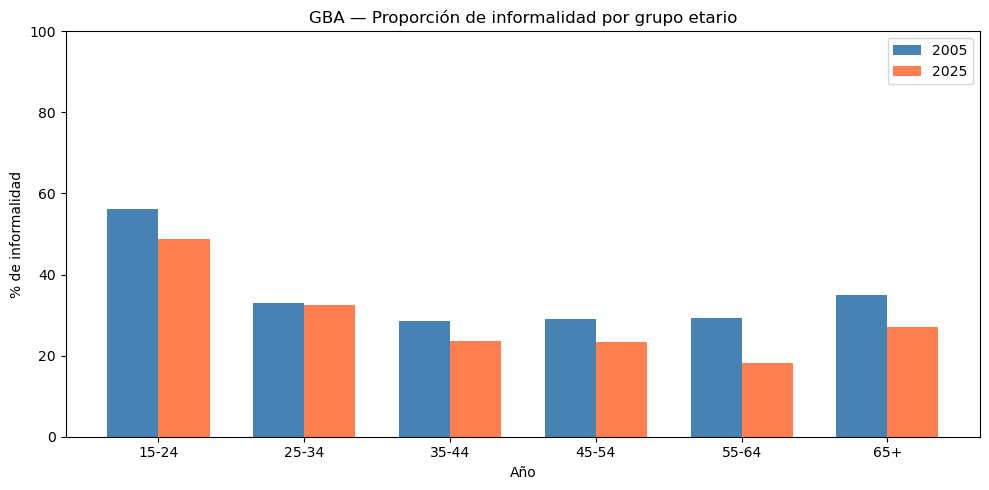

In [73]:
# TABLA DE ESTADÍSTICAS DESCRIPTIVAS

# Separar por año
ocu_2005 = ocupados[ocupados['ANO4'] == 2005].copy()
ocu_2025 = ocupados[ocupados['ANO4'] == 2025].copy()
 
def stats_informal(df, año):
    rows = []
    for inf_val, label in [(1, 'Informal'), (0, 'Formal')]:
        sub = df[df['informal'] == inf_val]
        rows.append({
            'Año'                        : año,
            'Condición'                  : label,
            'N'                          : len(sub),
            'Edad promedio'              : round(sub['CH06'].mean(), 1),
            'Ingreso ocup. ppal. promedio': round(sub['P21'].mean(), 1),
            'Ingreso p.c.f. promedio'    : round(sub['IPCF'].mean(), 1),
            '% Mujeres'                  : round((sub['CH04'] == 2).mean() * 100, 1),
            'Nivel educ. promedio'       : round(sub['NIVEL_ED'].mean(), 1),
        })
    return rows
 
tabla = pd.DataFrame(stats_informal(ocu_2005, 2005) + stats_informal(ocu_2025, 2025))
tabla = tabla.set_index(['Año', 'Condición'])
 
print("ESTADÍSTICAS DESCRIPTIVAS POR CONDICIÓN DE INFORMALIDAD")
print(tabla.to_string())
 

# GRÁFICO 1: Proporción de informalidad por nivel educativo.

# Mapa de etiquetas para nivel educativo.
nivel_labels = {
    1: 'Primario incompleto',
    2: 'Primario completo',
    3: 'Secundario incompleto',
    4: 'Secundario completo',
    5: 'Superior incompleto',
    6: 'Superior completo',
    7: 'Sin instrucción'
}
 
ocu_2005['NIVEL_ED_label'] = ocu_2005['NIVEL_ED'].map(nivel_labels)
ocu_2025['NIVEL_ED_label'] = ocu_2025['NIVEL_ED'].map(nivel_labels)
 
inf_nivel_2005 = ocu_2005.groupby('NIVEL_ED_label')['informal'].mean() * 100
inf_nivel_2025 = ocu_2025.groupby('NIVEL_ED_label')['informal'].mean() * 100
 
orden = ['Sin instrucción', 'Primario incompleto', 'Primario completo',
         'Secundario incompleto', 'Secundario completo', 'Superior incompleto', 'Superior completo']
 
inf_nivel_2005 = inf_nivel_2005.reindex(orden).dropna()
inf_nivel_2025 = inf_nivel_2025.reindex(orden).dropna()
 
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(orden))
width = 0.35
 
bars_2005 = ax.bar([i - width/2 for i in x], inf_nivel_2005, width,
                   label='2005', color='steelblue')
bars_2025 = ax.bar([i + width/2 for i in x], inf_nivel_2025, width,
                   label='2025', color='coral')
 
ax.set_xticks(list(x))
ax.set_xticklabels(orden, rotation=30, ha='right')
ax.set_ylabel('% de informalidad')
ax.set_title('GBA — Proporción de informalidad por nivel educativo')
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('informalidad_por_nivel_ed.png', dpi=150, bbox_inches='tight')
plt.show()
 
# GRÁFICO 2: Proporción de informalidad.

bins   = [14, 24, 34, 44, 54, 64, 100]
labels = ['15-24', '25-34', '35-44', '45-54', '55-64', '65+']
 
ocu_2005['grupo_etario'] = pd.cut(ocu_2005['CH06'], bins=bins, labels=labels)
ocu_2025['grupo_etario'] = pd.cut(ocu_2025['CH06'], bins=bins, labels=labels)
 
inf_edad_2005 = ocu_2005.groupby('grupo_etario', observed=True)['informal'].mean() * 100
inf_edad_2025 = ocu_2025.groupby('grupo_etario', observed=True)['informal'].mean() * 100
 
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(labels))
 
ax.bar([i - width/2 for i in x], inf_edad_2005, width,
       label='2005', color='steelblue')
ax.bar([i + width/2 for i in x], inf_edad_2025, width,
       label='2025', color='coral')
 
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('% de informalidad')
ax.set_title('GBA — Proporción de informalidad por grupo etario')
ax.legend()
ax.set_ylim(0, 100)
ax.set_xlabel('Año')
plt.tight_layout()
plt.savefig('informalidad_por_edad.png', dpi=150, bbox_inches='tight')
plt.show()


# Parte 4: Herramientas de IA y reflexión final 
Disponible en el archivo de LaTeX. 